In [25]:
import lightgbm as lgb
import numpy as np
from scipy.stats import norm
import pandas as pd
from sklearn.metrics import mean_pinball_loss
pd.set_option('display.max_columns', None)

In [26]:
train = pd.read_parquet("../data/model_input/train.parquet")
val = pd.read_parquet("../data/model_input/validation.parquet")
test = pd.read_parquet("../data/model_input/test.parquet")

In [27]:
FEATURE_COLS = [
    'net_gex_norm', 'net_dex_norm', 'net_tex_norm',
    'atm_iv', 'iv_call_25d', 'iv_put_25d', 'iv_skew_25d', 'iv_smile_curvature_25d',
    'ttm_min', 'theta_decay', 'log_return_from_open',
    'oi_concentration_top3', 'put_oi_fraction', 'atm_spread_norm',
    'distance_to_max_oi_norm', 'put_max_oi_strike_norm', 'call_max_oi_strike_norm',
]
TARGET = 'log_return_norm'
X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_val, y_val = val[FEATURE_COLS], val[TARGET]
X_test, y_test = test[FEATURE_COLS], test[TARGET]

In [28]:
QUANTILES = [0.1, 0.25, 0.5, 0.75, 0.9]
params = dict(objective='quantile', learning_rate=0.03, num_leaves=15,
              min_child_samples=100, subsample=0.8, subsample_freq=1,
              colsample_bytree=0.8, n_estimators=2000, verbose=-1)

models = {}
for q in QUANTILES:
    models[q] = lgb.LGBMRegressor(alpha=q, **params).fit(
        X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='quantile',
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[154]	valid_0's quantile: 0.173003
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[45]	valid_0's quantile: 0.323734
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[33]	valid_0's quantile: 0.386719
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1]	valid_0's quantile: 0.305552
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1]	valid_0's quantile: 0.190269


In [29]:
Z = np.column_stack([models[q].predict(X_test) for q in QUANTILES])
# Z = np.sort(Z, axis=1)
Z

array([[-0.35470393, -0.17717754,  0.19291307,  0.50436913,  1.08296887],
       [-0.45055555, -0.26526725,  0.07448314,  0.51650669,  1.08296887],
       [-0.44130392, -0.28096922,  0.07448314,  0.51650669,  1.08296887],
       ...,
       [-0.90224548, -0.54652578, -0.01514016,  0.51295035,  1.11563994],
       [-1.18864715, -0.56502746, -0.15864454,  0.52214939,  1.11563994],
       [-1.29189476, -0.73497561, -0.21072133,  0.51295035,  1.11563994]],
      shape=(375, 5))

In [30]:
res = test.copy()
for i, q in enumerate(QUANTILES):
    res[f'z_q{int(q*100)}']     = Z[:, i]
    logret_q                    = Z[:, i] * res['norm_factor'].to_numpy()
    res[f'price_q{int(q*100)}'] = res['underlying_price'].to_numpy() * np.exp(logret_q)

res[['expiration','underlying_price','price_q10','price_q25','price_q50','price_q75','price_q90']]

,expiration,underlying_price,price_q10,price_q25,price_q50,price_q75,price_q90
0,2026-04-29,710.05,707.981337,709.015931,711.177622,713.001935,716.403439
1,2026-04-29,710.76,708.158288,709.227072,711.191019,713.754305,717.052719
2,2026-04-29,711.14,708.640238,709.547434,711.562778,714.076950,717.311903
3,2026-04-29,711.46,708.559305,709.575999,711.876791,714.355282,717.544138
4,2026-04-29,711.85,708.794473,709.945626,712.062374,714.728934,717.899701
...,...,...,...,...,...,...,...
370,2026-05-19,735.84,734.342880,734.869222,735.810841,736.929704,738.170255
371,2026-05-19,734.42,732.540223,733.159594,734.199115,735.552651,736.868684
372,2026-05-19,736.02,734.622206,735.172984,735.996522,736.815868,737.752071
373,2026-05-19,734.77,733.447556,734.141075,734.593360,735.351677,736.013388


In [31]:
MU = 0.04
MIN_PER_YEAR = 365 * 1440

ttm_years = test['ttm_min'] / MIN_PER_YEAR
bs_mean = MU * ttm_years / test['norm_factor'] - 0.5 * test['norm_factor']

print("Pinball loss — Black-Scholes baseline vs model (test set):")

bs_losses, model_losses = [], []
for q in QUANTILES:
    bs_loss    = mean_pinball_loss(y_test, bs_mean + norm.ppf(q), alpha=q)
    model_loss = mean_pinball_loss(y_test, models[q].predict(X_test), alpha=q)
    bs_losses.append(bs_loss)
    model_losses.append(model_loss)
    print(f"  q={q:.2f}  BS={bs_loss:.4f}  model={model_loss:.4f}")

print(f"\n  avg    BS={np.mean(bs_losses):.4f}  model={np.mean(model_losses):.4f}")


Pinball loss — Black-Scholes baseline vs model (test set):
  q=0.10  BS=0.1647  model=0.1468
  q=0.25  BS=0.3006  model=0.2773
  q=0.50  BS=0.3543  model=0.3515
  q=0.75  BS=0.2873  model=0.2893
  q=0.90  BS=0.1571  model=0.1623

  avg    BS=0.2528  model=0.2454


Matched 375 / 375 rows to max-OI strike
Call ask available: 358, Put ask available: 374

────────────────────────────────────────────
  Model (q25/q75)
────────────────────────────────────────────
  Timestamps evaluated : 375
  Trades executed      : 286
  Win rate             : 45.1%
  Total P&L            : $-3,944.00
  Mean P&L / trade     : $-13.79
  Median P&L / trade   : $-27.00
  Std P&L / trade      : $220.96
  Sharpe (per trade)   : -0.062

────────────────────────────────────────────
  Black-Scholes (d2)
────────────────────────────────────────────
  Timestamps evaluated : 375
  Trades executed      : 273
  Win rate             : 44.7%
  Total P&L            : $-4,569.00
  Mean P&L / trade     : $-16.74
  Median P&L / trade   : $-28.00
  Std P&L / trade      : $224.19
  Sharpe (per trade)   : -0.075


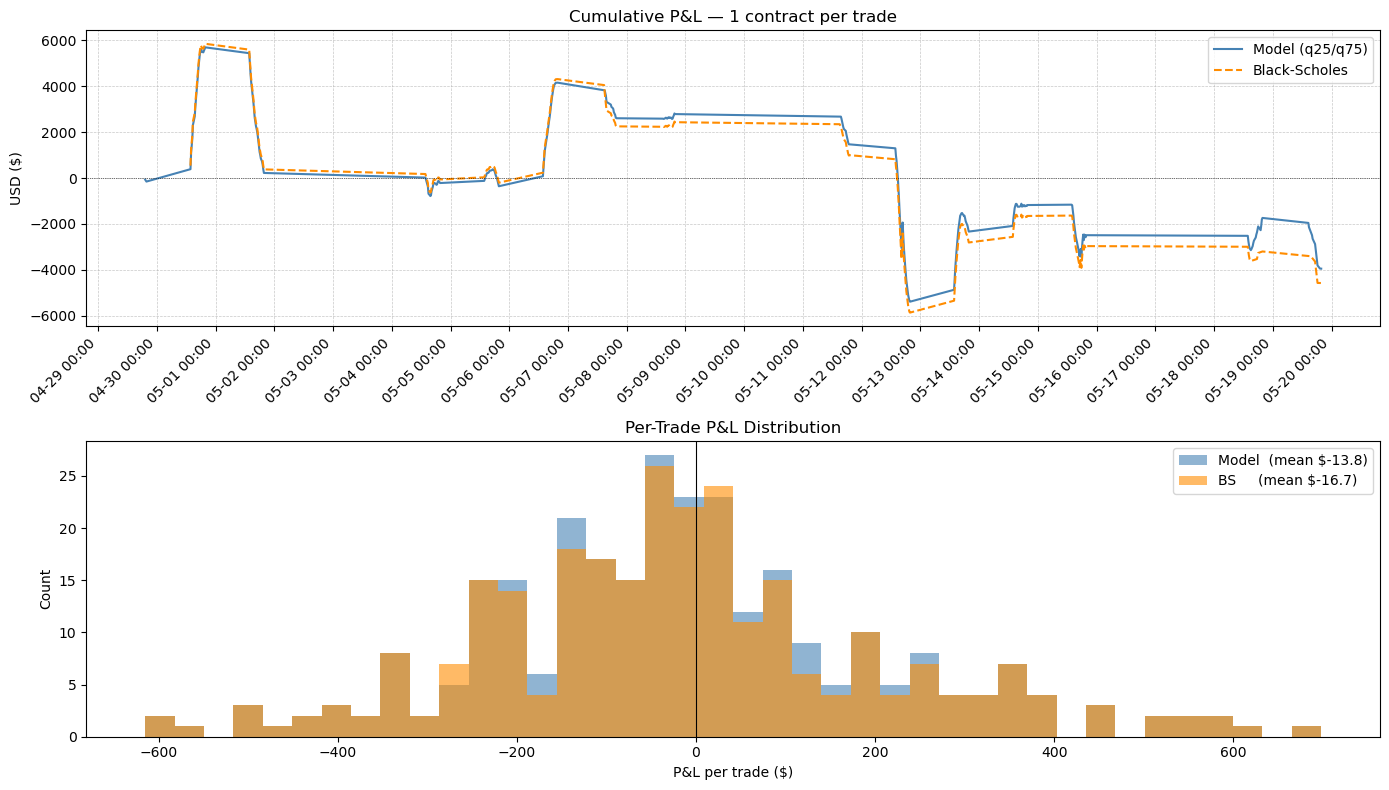

In [32]:
# ── Simulation: buy max-OI strike option when model/BS predicts >75% chance of profit ──

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

CONTRACT_SIZE = 100
R = 0.04
_MIN_PER_YEAR = 365 * 1440

# ── Load spy_processed for option chain lookup ──────────────────────────────
spy = pd.read_parquet("../data/processed/spy_processed.parquet")
spy['timestamp'] = pd.to_datetime(spy['timestamp'])

# ── Build simulation dataframe — timestamp now kept in test.parquet ──────────
res = test.copy()
res['timestamp'] = pd.to_datetime(res['timestamp'])

# ── Find max total-OI strike (calls + puts) per timestamp ───────────────────
strike_oi = (
    spy.groupby(['timestamp', 'strike'])['open_interest']
    .sum()
    .reset_index(name='total_oi')
)
# sort then drop_duplicates avoids idxmax() returning NaN on edge cases
max_oi_rows = (
    strike_oi
    .sort_values('total_oi', ascending=False)
    .drop_duplicates(subset='timestamp', keep='first')
    [['timestamp', 'strike']]
    .rename(columns={'strike': 'max_oi_strike'})
)

# ── Get ask prices at max-OI strike per option type ─────────────────────────
def ask_at_strike(right):
    return (
        spy[spy['right'] == right]
        .groupby(['timestamp', 'strike'])['ask']
        .mean()
        .reset_index()
        .rename(columns={'ask': f'{right.lower()}_ask', 'strike': 'max_oi_strike'})
    )

call_asks = ask_at_strike('CALL')
put_asks  = ask_at_strike('PUT')
spy_close = spy.groupby('timestamp')['spy_close'].first().reset_index()

res = (
    res
    .merge(max_oi_rows, on='timestamp', how='left')
    .merge(call_asks,   on=['timestamp', 'max_oi_strike'], how='left')
    .merge(put_asks,    on=['timestamp', 'max_oi_strike'], how='left')
    .merge(spy_close,   on='timestamp', how='left')
)

print(f"Matched {res['max_oi_strike'].notna().sum()} / {len(res)} rows to max-OI strike")
print(f"Call ask available: {res['call_ask'].notna().sum()}, Put ask available: {res['put_ask'].notna().sum()}")

# ── Model signal: q25 > K → buy call (>75% ITM); q75 < K → buy put (>75% ITM) ──
z25 = models[0.25].predict(res[FEATURE_COLS])
z75 = models[0.75].predict(res[FEATURE_COLS])
price_q25 = res['underlying_price'].values * np.exp(z25 * res['norm_factor'].values)
price_q75 = res['underlying_price'].values * np.exp(z75 * res['norm_factor'].values)

res['model_signal'] = np.where(
    price_q25 > res['max_oi_strike'], 'CALL',
    np.where(price_q75 < res['max_oi_strike'], 'PUT', None)
)

# ── Black-Scholes signal: N(d2) > 0.75 → buy call; N(d2) < 0.25 → buy put ──
S     = res['underlying_price'].values
K     = res['max_oi_strike'].values
T     = res['ttm_min'].values / _MIN_PER_YEAR
sigma = res['atm_iv'].values
with np.errstate(divide='ignore', invalid='ignore'):
    d2 = (np.log(S / K) + (R - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
THRESHOLD = norm.ppf(0.75)  # ≈ 0.6745
res['bs_signal'] = np.where(d2 > THRESHOLD, 'CALL', np.where(d2 < -THRESHOLD, 'PUT', None))

# ── P&L in dollar terms (1 contract = 100 shares) ───────────────────────────
def compute_pnl(df, signal_col):
    S_close = df['spy_close'].values
    K_arr   = df['max_oi_strike'].values
    ca      = df['call_ask'].values
    pa      = df['put_ask'].values
    sig     = df[signal_col].values

    mask_call = (sig == 'CALL') & ~pd.isna(df['call_ask']).values
    mask_put  = (sig == 'PUT')  & ~pd.isna(df['put_ask']).values

    pnl = np.zeros(len(df))
    pnl[mask_call] = (np.maximum(S_close[mask_call] - K_arr[mask_call], 0) - ca[mask_call]) * CONTRACT_SIZE
    pnl[mask_put]  = (np.maximum(K_arr[mask_put] - S_close[mask_put],  0) - pa[mask_put])  * CONTRACT_SIZE

    return pd.Series(pnl, index=df.index), pd.Series(mask_call | mask_put, index=df.index)

res['model_pnl'],  res['model_traded']  = compute_pnl(res, 'model_signal')
res['bs_pnl'],     res['bs_traded']     = compute_pnl(res, 'bs_signal')

# ── Summary statistics ───────────────────────────────────────────────────────
for label, pnl_col, traded_col in [
    ('Model (q25/q75)', 'model_pnl', 'model_traded'),
    ('Black-Scholes (d2)', 'bs_pnl', 'bs_traded'),
]:
    mask = res[traded_col]
    pnl  = res.loc[mask, pnl_col]
    print(f"\n{'─'*44}")
    print(f"  {label}")
    print(f"{'─'*44}")
    print(f"  Timestamps evaluated : {len(res)}")
    print(f"  Trades executed      : {mask.sum()}")
    print(f"  Win rate             : {(pnl > 0).mean():.1%}")
    print(f"  Total P&L            : ${pnl.sum():,.2f}")
    print(f"  Mean P&L / trade     : ${pnl.mean():,.2f}")
    print(f"  Median P&L / trade   : ${pnl.median():,.2f}")
    print(f"  Std P&L / trade      : ${pnl.std():,.2f}")
    print(f"  Sharpe (per trade)   : {pnl.mean() / pnl.std():.3f}")

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

model_traded = res[res['model_traded']]
bs_traded    = res[res['bs_traded']]

axes[0].plot(model_traded['timestamp'], model_traded['model_pnl'].cumsum(),
             label='Model (q25/q75)', color='steelblue')
axes[0].plot(bs_traded['timestamp'], bs_traded['bs_pnl'].cumsum(),
             label='Black-Scholes', color='darkorange', linestyle='--')
axes[0].axhline(0, color='k', linewidth=0.5, linestyle=':')
axes[0].set_title('Cumulative P&L — 1 contract per trade')
axes[0].set_ylabel('USD ($)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
axes[0].xaxis.set_major_locator(mdates.DayLocator())
axes[0].grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

axes[1].hist(model_traded['model_pnl'].values, bins=40, alpha=0.6,
             label=f'Model  (mean ${model_traded["model_pnl"].mean():.1f})', color='steelblue')
axes[1].hist(bs_traded['bs_pnl'].values, bins=40, alpha=0.6,
             label=f'BS     (mean ${bs_traded["bs_pnl"].mean():.1f})',       color='darkorange')
axes[1].axvline(0, color='k', linewidth=0.8)
axes[1].set_title('Per-Trade P&L Distribution')
axes[1].set_xlabel('P&L per trade ($)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()


────────────────────────────────────────────
  Model (q25/q75)  [excl. 5/1, 5/12]
────────────────────────────────────────────
  Timestamps evaluated : 325
  Trades executed      : 236
  Win rate             : 53.8%
  Total P&L            : $8,369.00
  Mean P&L / trade     : $35.46
  Median P&L / trade   : $7.00
  Std P&L / trade      : $188.09
  Sharpe (per trade)   : 0.189

────────────────────────────────────────────
  Black-Scholes (d2)  [excl. 5/1, 5/12]
────────────────────────────────────────────
  Timestamps evaluated : 325
  Trades executed      : 223
  Win rate             : 53.8%
  Total P&L            : $7,744.00
  Mean P&L / trade     : $34.73
  Median P&L / trade   : $7.00
  Std P&L / trade      : $191.26
  Sharpe (per trade)   : 0.182


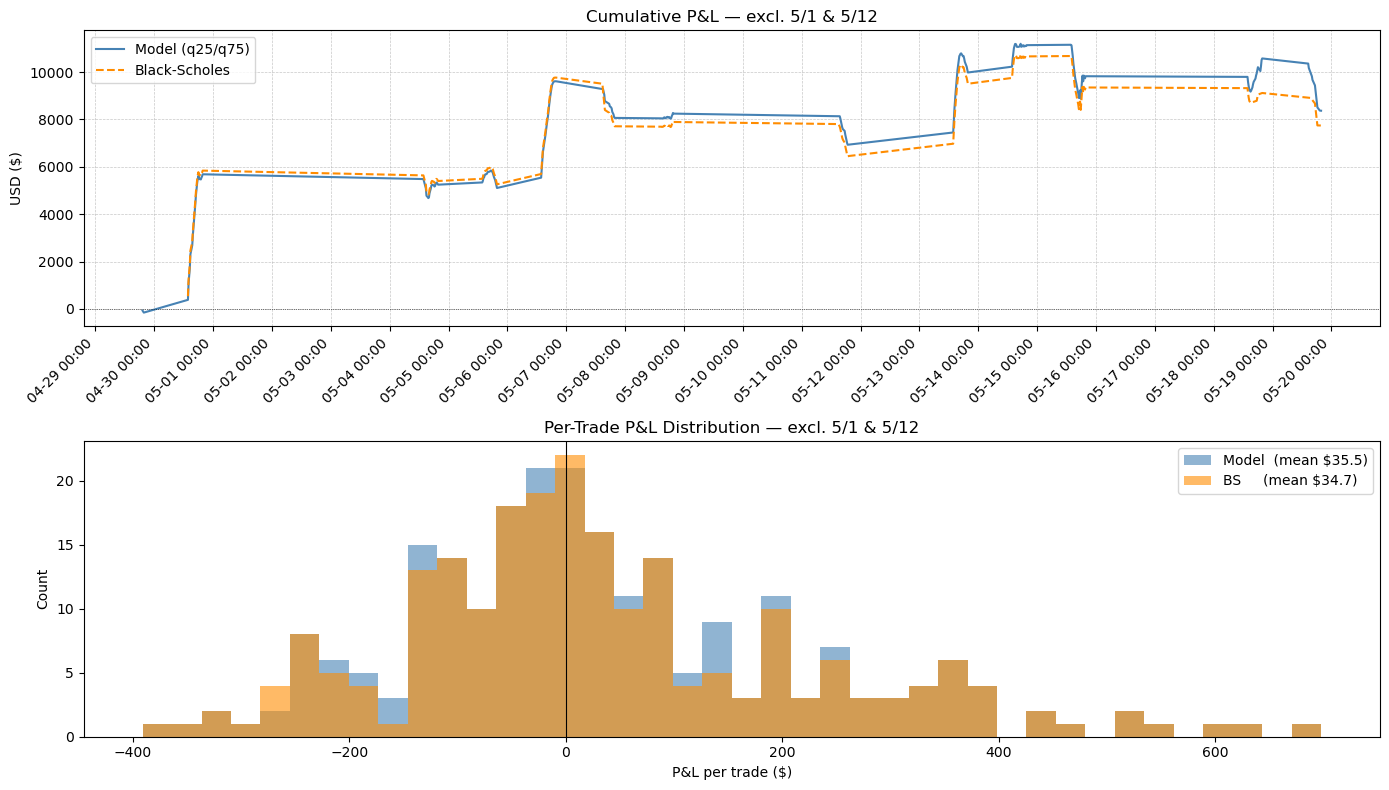

In [33]:
# ── Simulation excluding 5/1 and 5/12 ───────────────────────────────────────
from datetime import date

EXCLUDE_DATES = {date(2026, 5, 1), date(2026, 5, 12)}
res_f = res[~res['timestamp'].dt.date.isin(EXCLUDE_DATES)].copy()

res_f['model_pnl'], res_f['model_traded'] = compute_pnl(res_f, 'model_signal')
res_f['bs_pnl'],    res_f['bs_traded']    = compute_pnl(res_f, 'bs_signal')

for label, pnl_col, traded_col in [
    ('Model (q25/q75)', 'model_pnl', 'model_traded'),
    ('Black-Scholes (d2)', 'bs_pnl', 'bs_traded'),
]:
    mask = res_f[traded_col]
    pnl  = res_f.loc[mask, pnl_col]
    print(f"\n{'─'*44}")
    print(f"  {label}  [excl. 5/1, 5/12]")
    print(f"{'─'*44}")
    print(f"  Timestamps evaluated : {len(res_f)}")
    print(f"  Trades executed      : {mask.sum()}")
    print(f"  Win rate             : {(pnl > 0).mean():.1%}")
    print(f"  Total P&L            : ${pnl.sum():,.2f}")
    print(f"  Mean P&L / trade     : ${pnl.mean():,.2f}")
    print(f"  Median P&L / trade   : ${pnl.median():,.2f}")
    print(f"  Std P&L / trade      : ${pnl.std():,.2f}")
    print(f"  Sharpe (per trade)   : {pnl.mean() / pnl.std():.3f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

model_traded_f = res_f[res_f['model_traded']]
bs_traded_f    = res_f[res_f['bs_traded']]

axes[0].plot(model_traded_f['timestamp'], model_traded_f['model_pnl'].cumsum(),
             label='Model (q25/q75)', color='steelblue')
axes[0].plot(bs_traded_f['timestamp'], bs_traded_f['bs_pnl'].cumsum(),
             label='Black-Scholes', color='darkorange', linestyle='--')
axes[0].axhline(0, color='k', linewidth=0.5, linestyle=':')
axes[0].set_title('Cumulative P&L — excl. 5/1 & 5/12')
axes[0].set_ylabel('USD ($)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
axes[0].xaxis.set_major_locator(mdates.DayLocator())
axes[0].grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

axes[1].hist(model_traded_f['model_pnl'].values, bins=40, alpha=0.6,
             label=f'Model  (mean ${model_traded_f["model_pnl"].mean():.1f})', color='steelblue')
axes[1].hist(bs_traded_f['bs_pnl'].values, bins=40, alpha=0.6,
             label=f'BS     (mean ${bs_traded_f["bs_pnl"].mean():.1f})',        color='darkorange')
axes[1].axvline(0, color='k', linewidth=0.8)
axes[1].set_title('Per-Trade P&L Distribution — excl. 5/1 & 5/12')
axes[1].set_xlabel('P&L per trade ($)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()